## Imports

In [64]:
import pandas as pd

In [65]:
df = pd.read_csv("../data/raw.csv")

In [66]:
df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
26575,0xad04,JAPRES03DEL03,24,4.6,26.913483,75.803139,26.943483,75.833139,01-04-2022,19:15:00,19:20:00,conditions Fog,Jam,0,Meal,motorcycle,1,No,Urban,(min) 29
6320,0x61cf,CHENRES04DEL01,29,4.6,13.029780,80.208812,13.069780,80.248812,30-03-2022,12:40:00,12:45:00,conditions Windy,High,1,Buffet,scooter,0,No,Metropolitian,(min) 23
2335,0x1c71,BANGRES08DEL01,24,4.6,12.906229,77.596791,12.916229,77.606791,09-03-2022,09:40:00,09:50:00,conditions Fog,Low,0,Snack,motorcycle,0,No,Metropolitian,(min) 18
31814,0xa203,BANGRES13DEL02,33,4.1,12.935662,77.614130,12.955662,77.634130,07-03-2022,08:55:00,09:10:00,conditions Stormy,Low,0,Drinks,motorcycle,1,No,Metropolitian,(min) 25
2132,0x9ae0,PUNERES07DEL01,25,4.6,18.546947,73.900626,18.616947,73.970626,20-03-2022,22:10:00,22:25:00,conditions Sandstorms,Low,2,Drinks,motorcycle,1,No,Urban,(min) 16


In [67]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

## Data Assesment

- To understand data more deeply before implimenting steps to clean.
- Discover & Document what to clean

1. Summary
2. Column description
3. Assesment:
    - Manual
    - Programatic 
4. Discover & Document
    - write about the uncleaned data as below:

    - **Types of uncleaned data**
        1. Dirty Data: data with quality issues like duplicate data, missing data, inaccurate data like -ve value in height col
            - Dirty Data has 4 types which is called Data Quality Dimensions
                1. Completness: missing value
                2. Validity: invalid data like -ve height or duplicate patient id etc
                3. Accuracy: valid but not accurate like weight 2kg or height 2foot, its valid but not accurate
                4. Consistency: both valid & accurate not inconsistent like state written as NY & New York

        2. Messy Data: data with structural issues
            - Each variable forms a column: In above example, china india & pakistan are all countries means single variable but spread around columns with null values whereas ideally it should be in 1 col called country
            - Each observation forms a row: like student data, single student data should be in same row
            - Each observation unit forms a table: there should not be multiple tables for the same data otherwise we will have to merge

### Summary

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [69]:
df.shape

(45593, 20)

In [70]:
print(df.isnull().sum())
print()
print(df.duplicated().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

0


- Some columns data type are not correct
- No null or duplicated values
- data shape: 45593/20 

### Column Description

In [71]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [72]:
df.sample(3)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
36375,0xcdc9,AURGRES13DEL03,30,4.8,19.880256,75.323503,19.910256,75.353503,11-02-2022,22:40:00,22:50:00,conditions Stormy,Low,2,Snack,scooter,1,No,Metropolitian,(min) 26
16688,0x65cb,PUNERES11DEL01,28,4.8,18.533811,73.899315,18.573811,73.939315,13-03-2022,16:40:00,16:45:00,conditions Stormy,Medium,0,Meal,motorcycle,1,No,Metropolitian,(min) 20
39681,0x433d,SURRES13DEL03,24,5,21.170096,72.789122,21.230096,72.849122,05-04-2022,17:10:00,17:25:00,conditions Cloudy,Medium,1,Drinks,motorcycle,0,No,Metropolitian,(min) 17


- ID: order id
- Delivery_person_ID: Delivery_person_ID
- Delivery_person_Age: Delivery_person_Age
- Delivery_person_Ratings: Delivery_person_Ratings
- Restaurant_latitude: Restaurant_latitude
- Restaurant_longitude: Restaurant_longitude
- Delivery_location_latitude: Delivery_location_latitude
- Delivery_location_longitude: Delivery_location_longitude
- Order_Date: Order_Date 
- Time_Orderd: Time_Orderd
- Time_Order_picked: Time_Order_picked
- Weatherconditions: Weatherconditions
- Road_traffic_density: Road_traffic_density
- Vehicle_condition: Vehicle_condition 
- Type_of_order: Type_of_order
- Type_of_vehicle: Type_of_vehicle
- multiple_deliveries: multiple_deliveries
- Festival: Festival
- City: City
- Time_taken(min): Time_taken(min)

### Assesment

- Delivery_person_Age: dtype should be int
- Delivery_person_Ratings: contains missing values and dtype should be float
- Restaurant_latitude: some values are negative and 0
- Restaurant_longitude: some values are 0
- Delivery_location_latitude: some values are 0
- Delivery_location_longitude: some values are 0
- Order_Date: dtype should be datetime
- Time_Orderd: dtype should be datetime
- Time_Order_picked: dtype should be datetime
- Weatherconditions: remove "conditions " & contains null values
- Road_traffic_density: contains null values
- Vehicle_condition: contains ordinal data
- Type_of_order: contains string
- Type_of_vehicle: contains string
- multiple_deliveries: binary data & contains null values
- Festival: change to binary 0 & 1 + contains null values
- City: contains null values
- Time_taken(min): remove "(min) "

## Data Cleaning

- **When Performing data cleaning, Follow this order:**
    - Fix missing values
    - Fix all Messy data (structural issues)
    - Fix Validity issues
    - Fix Accuracy issues
    - Fix Consistency issues

#### Missing value Fix

In [73]:
import numpy as np

missing_df = (
    df.replace("NaN", np.NaN)
    .assign(
        Weatherconditions=lambda df_: (
            df_['Weatherconditions']
            .str.replace("conditions ", "")
            .replace("NaN", np.NaN)
        ),
        Festival=lambda df_: df_['Festival'].str.strip().replace("NaN", np.NaN),
        multiple_deliveries=lambda df_: pd.to_numeric(df_['multiple_deliveries'], errors='coerce')
    )
)

<Axes: >

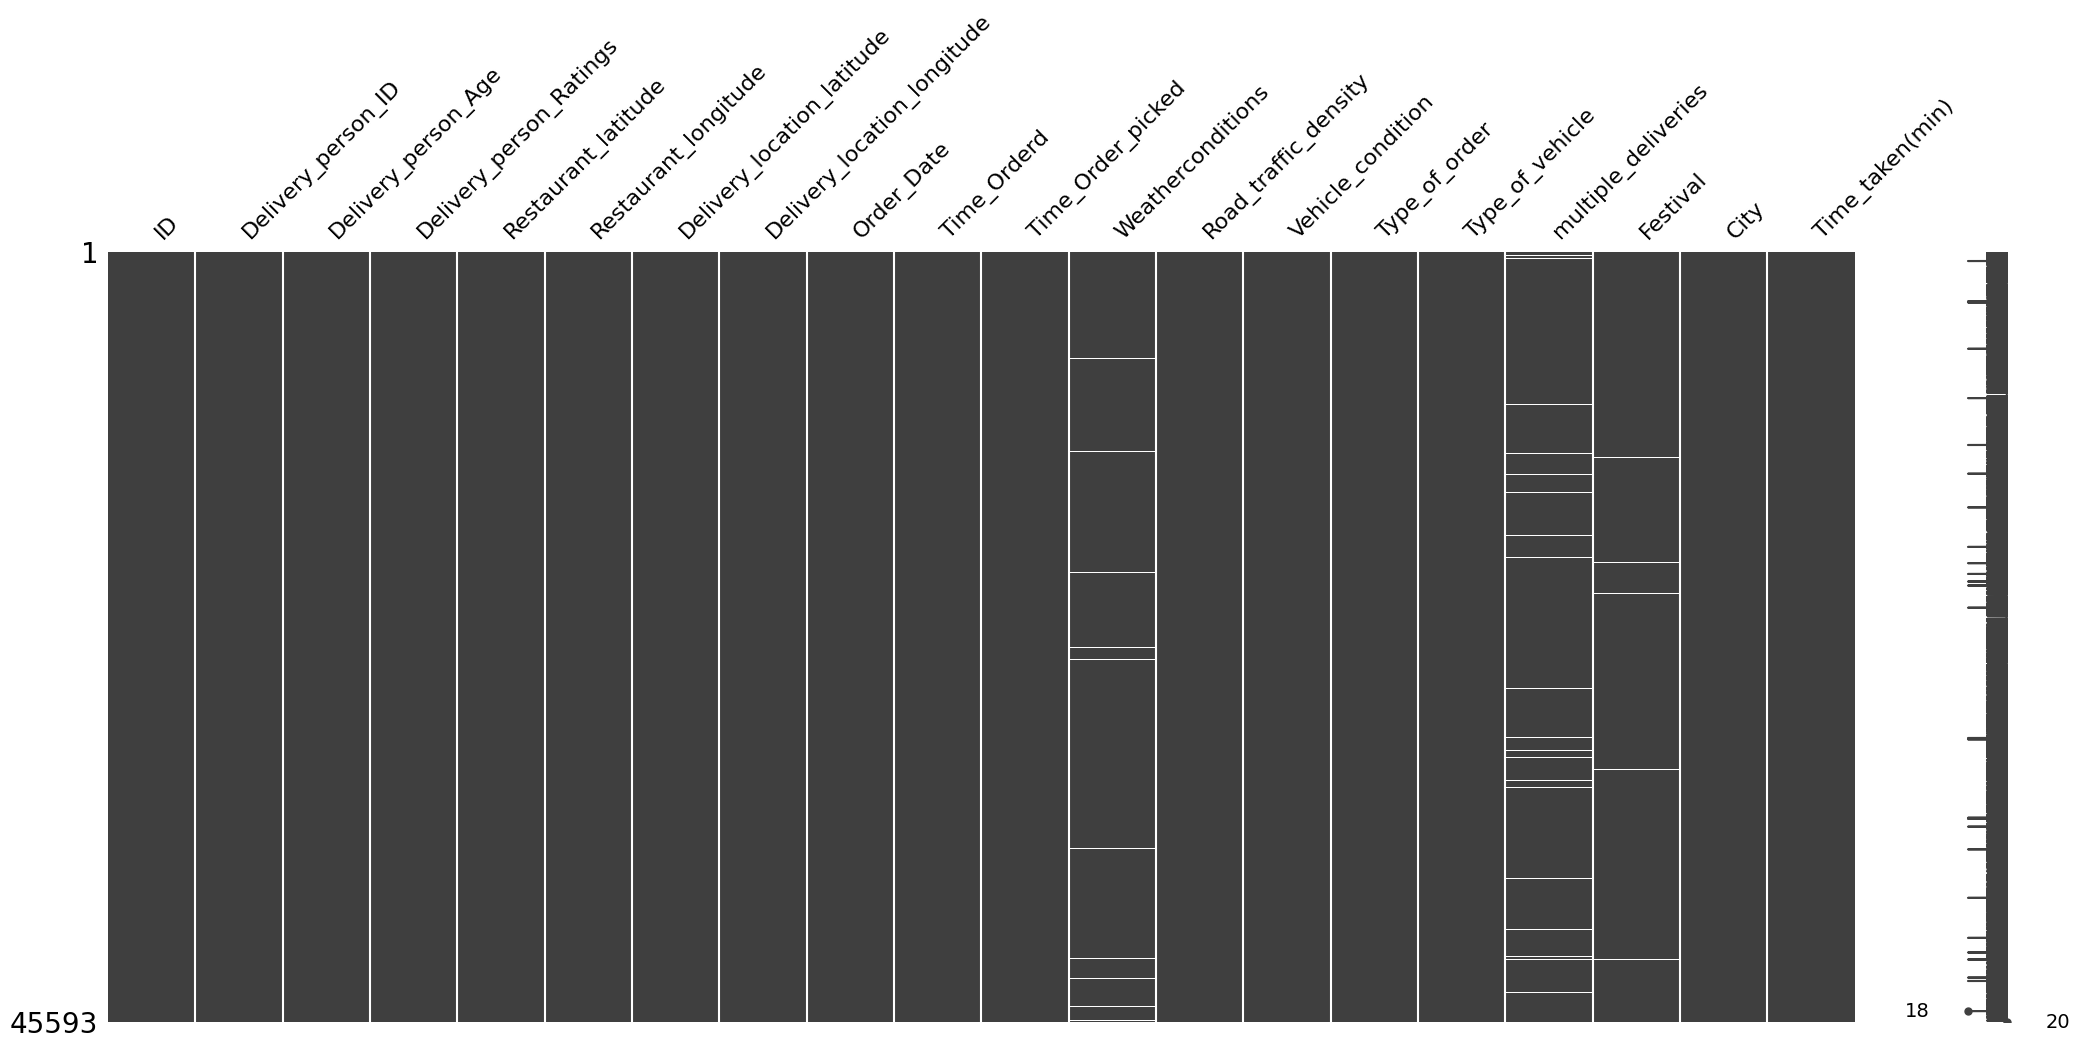

In [74]:
import missingno as msno
msno.matrix(missing_df)

##### Delivery_person_Ratings

- ratings are zero they are not nan

##### Latitude/Longitude/City

- Restaurant_latitude: some values are negative and 0
- Restaurant_longitude: some values are 0
- Delivery_location_latitude: some values are 0
- Delivery_location_longitude: some values are 0

In [75]:
# Check if city is also zero/missing when coordinates are zero
coord_cols = ['Restaurant_latitude', 'Restaurant_longitude', 
              'Delivery_location_latitude', 'Delivery_location_longitude']

In [76]:
# See rows where any coordinate is 0
zero_coords = df[(df['Restaurant_latitude'] == 0) | 
                  (df['Restaurant_longitude'] == 0) |
                  (df['Delivery_location_latitude'] == 0) | 
                  (df['Delivery_location_longitude'] == 0)]

zero_coords[coord_cols + ['City']].head(20)

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,City
33,0.0,0.0,0.11,0.11,Urban
52,0.0,0.0,0.03,0.03,Metropolitian
57,0.0,0.0,0.08,0.08,Semi-Urban
59,0.0,0.0,0.06,0.06,Metropolitian
67,0.0,0.0,0.02,0.02,Metropolitian
68,0.0,0.0,0.04,0.04,Urban
72,0.0,0.0,0.08,0.08,Urban
73,0.0,0.0,0.02,0.02,Metropolitian
76,0.0,0.0,0.05,0.05,Metropolitian
81,0.0,0.0,0.11,0.11,Metropolitian


In [77]:
# we can not impute missing values in lat long since we dont have city name, we only have city category
# best option is to remove those with 0

In [78]:
# Remove rows where any coordinate is 0.0
print(df.shape)

df = df[
    (df['Restaurant_latitude'] != 0) & 
    (df['Restaurant_longitude'] != 0) & 
    (df['Delivery_location_latitude'] != 0) & 
    (df['Delivery_location_longitude'] != 0)
]

print(df.shape)

(45593, 20)
(41953, 20)


##### Weatherconditions

In [79]:
df['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64

In [80]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace("conditions ", "", regex=False)

In [81]:
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
NaN            569
Name: count, dtype: int64

In [82]:
# we can not impute this value so best option is to remove these rows

In [83]:
print(f"Before: {df.shape}")
df = df[df['Weatherconditions'] != "NaN"]
print(f"After: {df.shape}")

Before: (41953, 20)
After: (41384, 20)


##### Road_traffic_density

In [84]:
df['Road_traffic_density'].sample(16)

41426    Medium 
42918       Low 
27596       Jam 
43026       Low 
43232    Medium 
45387      High 
33839    Medium 
42233    Medium 
9268        Jam 
20529       Jam 
20994    Medium 
41481       Jam 
8545       High 
28410      High 
18364    Medium 
15775       Low 
Name: Road_traffic_density, dtype: object

In [85]:
#no missing value here

##### multiple_deliveries

In [86]:
df['multiple_deliveries'].value_counts()

multiple_deliveries
1       25583
0       12773
2        1815
NaN       893
3         320
Name: count, dtype: int64

In [87]:
# Clean the multiple_deliveries column
df['multiple_deliveries'] = pd.to_numeric(df['multiple_deliveries'], errors='coerce')

# Remove rows with NaN (converted from string 'NaN')
print(f"Before: {df.shape}")
df.dropna(subset=['multiple_deliveries'], inplace=True)
print(f"After: {df.shape}")

# Convert to integer
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)

# Check the result
print(df['multiple_deliveries'].value_counts())

Before: (41384, 20)
After: (40491, 20)
multiple_deliveries
1    25583
0    12773
2     1815
3      320
Name: count, dtype: int64


##### Festival

In [88]:
df['Festival'].value_counts()

Festival
No      39490
Yes       801
NaN       200
Name: count, dtype: int64

In [89]:
# Remove trailing spaces from Festival column
df['Festival'] = df['Festival'].str.strip()

print(df.shape)
# Now remove rows with "NaN"
df = df[df['Festival'] != "NaN"]
print(df.shape)

(40491, 20)
(40291, 20)


##### City

In [90]:
df['City'].value_counts()

City
Metropolitian     30241
Urban              8856
NaN                1046
Semi-Urban          148
Name: count, dtype: int64

In [91]:
# Remove trailing spaces from City column
df['City'] = df['City'].str.strip()

print(df.shape)
# Now remove rows with "NaN"
df = df[df['City'] != "NaN"]
print(df.shape)

(40291, 20)
(39245, 20)


In [92]:
# # Ordinal Encoding (to preserve urban hierarchy)
# city_order = {
#     'Semi-Urban': 1,    # Least urbanized
#     'Urban': 2,          # Moderately urbanized  
#     'Metropolitian': 3   # Most urbanized (note: typo in original - should be Metropolitan)
# }

# df['city_code'] = df['City'].map(city_order)

#### Fix all consistency issue

##### age

In [93]:
# Remove any spaces and convert to numeric
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'].astype(str).str.strip(), errors='coerce')

# Drop NaN if any
df.dropna(subset=['Delivery_person_Age'], inplace=True)

# Convert to int
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(int)

print(f"Age range: {df['Delivery_person_Age'].min()} to {df['Delivery_person_Age'].max()}")

Age range: 20 to 39


##### rating

In [94]:
# Remove spaces and convert to float
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'].astype(str).str.strip(), errors='coerce')

# Drop NaN if any
df.dropna(subset=['Delivery_person_Ratings'], inplace=True)

# Convert to float
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].astype(float)

print(f"Ratings range: {df['Delivery_person_Ratings'].min()} to {df['Delivery_person_Ratings'].max()}")

Ratings range: 2.5 to 5.0


##### Vehicle_condition (ordinal data)

In [95]:
df['Vehicle_condition'].value_counts()

Vehicle_condition
0    12813
2    12633
1    12618
Name: count, dtype: int64

##### Type_of_order and Type_of_vehicle 

In [96]:
df[['Type_of_order','Type_of_vehicle']].value_counts()

Type_of_order  Type_of_vehicle  
Meal           motorcycle           5649
Snack          motorcycle           5643
Buffet         motorcycle           5593
Drinks         motorcycle           5548
               scooter              3194
Meal           scooter              3183
Snack          scooter              3177
Buffet         scooter              3044
Drinks         electric_scooter      772
Buffet         electric_scooter      762
Snack          electric_scooter      757
Meal           electric_scooter      742
Name: count, dtype: int64

In [97]:
# For Delivery Time Prediction (Regression)
# Use Label Encoding (1,2,3,4) for both columns

In [98]:
# from sklearn.preprocessing import LabelEncoder

# # Label encode Type_of_order
# le_order = LabelEncoder()
# df['Type_of_order_encoded'] = le_order.fit_transform(df['Type_of_order'])
# print("Order type mapping:", dict(zip(le_order.classes_, le_order.transform(le_order.classes_))))

# # Label encode Type_of_vehicle
# le_vehicle = LabelEncoder()
# df['Type_of_vehicle_encoded'] = le_vehicle.fit_transform(df['Type_of_vehicle'])
# print("Vehicle type mapping:", dict(zip(le_vehicle.classes_, le_vehicle.transform(le_vehicle.classes_))))

##### multiple_deliveries

In [99]:
df['multiple_deliveries'].isnull().sum()

0

##### Festival

In [100]:
df['Festival'].value_counts()

Festival
No     37299
Yes      765
Name: count, dtype: int64

In [101]:
df['Festival'] = df['Festival'].str.strip()

In [102]:
# df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})

##### Time_taken(min)

In [103]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.replace("(min)", "")

##### Extract delivery city information from ID

In [104]:
df['Delivery_person_ID']

0          INDORES13DEL02 
1          BANGRES18DEL02 
2          BANGRES19DEL01 
3         COIMBRES13DEL02 
4          CHENRES12DEL01 
               ...        
45587    RANCHIRES16DEL01 
45588       JAPRES04DEL01 
45590      CHENRES08DEL03 
45591     COIMBRES11DEL01 
45592    RANCHIRES09DEL02 
Name: Delivery_person_ID, Length: 38064, dtype: object

In [105]:
# Extract city (everything before "RES")
df['delivery_city'] = df['Delivery_person_ID'].str.extract(r'^([A-Z]+)RES', expand=False)

# Or extract using split
df['delivery_city'] = df['Delivery_person_ID'].str.split('RES').str[0]

# Check the extracted cities
print(df['delivery_city'].value_counts())

delivery_city
JAP       3137
SUR       2908
HYD       2905
COIMB     2897
MUM       2880
BANG      2878
INDO      2860
PUNE      2839
CHEN      2835
MYS       2715
RANCHI    2313
VAD       1432
KOL        647
KOC        635
LUDH       627
KNP        616
GOA        547
AGR        513
ALH        511
AURG       502
DEH        436
BHP        431
Name: count, dtype: int64


In [106]:
# Create mapping dictionary for city codes
city_mapping = {
    'JAP': 'Jabalpur',
    'SUR': 'Surat',
    'HYD': 'Hyderabad',
    'COIMB': 'Coimbatore',
    'MUM': 'Mumbai',
    'BANG': 'Bangalore',
    'INDO': 'Indore',
    'PUNE': 'Pune',
    'CHEN': 'Chennai',
    'MYS': 'Mysore',
    'RANCHI': 'Ranchi',
    'VAD': 'Vadodara',
    'KOL': 'Kolkata',
    'KOC': 'Kochi',
    'LUDH': 'Ludhiana',
    'KNP': 'Kanpur',
    'GOA': 'Goa',
    'AGR': 'Agra',
    'ALH': 'Allahabad',
    'AURG': 'Aurangabad',
    'DEH': 'Dehradun',
    'BHP': 'Bhilai'
}

# Apply mapping
df['delivery_city'] = df['delivery_city'].map(city_mapping)

In [107]:
df['delivery_city'].isnull().sum()

0

In [108]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),delivery_city
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,Sunny,High,2,Snack,motorcycle,0,No,Urban,24,Indore
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33,Bangalore
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26,Bangalore
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21,Coimbatore
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30,Chennai


## After Cleaning

In [109]:
df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),delivery_city
31832,0x921d,BANGRES15DEL03,33,4.6,12.975377,77.696664,13.065377,77.786664,29-03-2022,22:25:00,...,Stormy,Low,1,Meal,scooter,1,No,Metropolitian,15,Bangalore
24040,0xccde,AURGRES05DEL01,38,3.5,19.875522,75.367127,19.985522,75.477127,16-02-2022,22:40:00,...,Cloudy,Low,1,Drinks,scooter,1,No,Metropolitian,34,Aurangabad
34398,0xa9f2,INDORES01DEL02,37,4.8,22.695207,75.866059,22.715207,75.886059,03-03-2022,11:55:00,...,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,32,Indore
19743,0x682a,BANGRES15DEL02,20,4.9,12.975377,77.696664,13.105377,77.826664,02-03-2022,22:50:00,...,Windy,Low,0,Snack,motorcycle,1,No,Metropolitian,22,Bangalore
26859,0xc919,GOARES17DEL02,36,4.9,15.496162,73.825364,15.576162,73.905364,14-02-2022,22:15:00,...,Stormy,Low,0,Drinks,motorcycle,0,No,Metropolitian,28,Goa


In [110]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)',
       'delivery_city'],
      dtype='object')

## Export data

In [111]:
df.to_csv("../data/cleaned.csv", index=False)